## Resumen
Este notebook ejecuta la comparacion de Malawi 1997 excluyendo extremos, para contrastar como cambia la alineacion con GlobalDist en bins y media cuando se reduce el peso de la cola alta.

# Malawi 1997: Survey Bins vs Global 1000-Bin Distribution

Objective: check whether the gap between the PIP mean and the 1000-bin mean for Malawi 1997 is coming from the top bin.

This notebook reconstructs 1000 equal-population bins from the Malawi 1997 survey/microdata, converts welfare to 2021 PPP USD per person per day, and compares each survey-reconstructed bin with the corresponding bin in the global 1000-bin file.

In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
ROOT = Path(".").resolve()
INPUT = ROOT / "01-input"
OUT = ROOT / "work"

mwi_path = INPUT / "country" / "MWI_1997.dta"
global_bins_path = INPUT / "GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta"
pip_path = INPUT / "pip_1kbins.dta"

mwi_path, global_bins_path, pip_path

(PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/country/MWI_1997.dta'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/GlobalDist1000bins_1990_2026_20260324_2021_01_02_PROD.dta'),
 PosixPath('/Users/danielaavayu/Desktop/World Bank/Bottom Coding/01-input/pip_1kbins.dta'))

## 1. Load Malawi 1997 Survey Data

The local Malawi file is microdata. The variable `welfare` is in local currency annual terms, so we convert it to daily 2021 PPP USD to match the global bins.

moneda local anual -> moneda local 2021 -> USD PPP 2021 anual -> USD PPP 2021 diario

In [40]:
mwi = pd.read_stata(mwi_path, convert_categoricals=False)

mwi[["welfare", "weight", "cpi2021", "icp2021", "year", "survname"]].head()

,welfare,weight,cpi2021,icp2021,year,survname
0,"7,068.1660",187.2218,0.0215,282.0942,"1,997.0000",IHS-I
1,"9,334.1377",374.4435,0.0215,282.0942,"1,997.0000",IHS-I
2,"6,705.0552",748.8870,0.0215,282.0942,"1,997.0000",IHS-I
3,"3,693.1663","1,310.5522",0.0215,282.0942,"1,997.0000",IHS-I
4,"5,462.6602",374.4435,0.0215,282.0942,"1,997.0000",IHS-I


In [41]:
tdf = mwi.sort_values("welfare", ascending=False)
tdf.head(10)

,countrycode,hhid,welfare,urban,hsize,wta_hh,weight,fdpindex,nfdpindex,pc_hhdr,subnatid,code,year,survname,cpi_domain,cpi_domain_value,cpi2021_unadj,cpi2017_unadj,cpi2011_unadj,cpi2011,cpi2017,cpi2021,icp2011,icp2017,icp2021,comparability,cpi_replication,cpi_domain_var,icpreplication,icpdomain_var,icpdomain_value,comparable,cpi2005,icp2005,cpi_data_level,cpi2011_SM26,cpi2017_SM26,cpi2021_SM26,icp2011_SM26,icp2017_SM26,icp2021_SM26
7694,MWI,"252,563,005,049.0000","118,420,360.0000",0,2,162.1831,324.3661,0.9230,0.9230,"321,180.0625",225 – Mchinji,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
10462,MWI,"343,406,801,173.0000","27,006,552.0000",0,1,148.4000,148.4000,1.1240,1.1240,"321,180.0625",134 – Karonga,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
9843,MWI,"313,110,008,237.0000","1,204,712.3750",1,2,75.5106,151.0213,2.2210,2.2210,"321,180.0625",131 – Mzuzu City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
7269,MWI,"242,418,065,255.0000","981,653.6250",1,7,261.0616,"1,827.4313",2.2210,2.2210,"321,180.0625",224 – Lilongwe City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
9812,MWI,"313,109,004,249.0000","713,340.8750",1,1,75.5106,75.5106,2.2210,2.2210,"321,180.0625",131 – Mzuzu City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
7379,MWI,"242,425,031,321.0000","428,542.3125",1,1,261.0616,261.0616,2.2210,2.2210,"192,950.1719",224 – Lilongwe City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
7120,MWI,"242,403,134,158.0000","374,757.7500",1,5,261.0616,"1,305.3081",2.2210,2.2210,"168,733.7969",224 – Lilongwe City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
1503,MWI,"50,514,195,012.0000","346,888.0312",1,1,196.6864,196.6864,2.2210,2.2210,"156,185.5156",305 – Blantyre City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
1487,MWI,"50,513,188,055.0000","345,174.0938",1,5,196.6864,983.4323,2.2210,2.2210,"155,413.8281",305 – Blantyre City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942
7124,MWI,"242,403,135,043.0000","288,622.6250",1,1,261.0616,261.0616,2.2210,2.2210,"129,951.6562",224 – Lilongwe City,MWI,"1,997.0000",IHS-I,1,1,NaN,NaN,NaN,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942,0,-9,,1,,1,0,NaN,NaN,2,0.1170,0.0314,0.0215,78.7030,241.9305,282.0942


In [42]:
cpi2021 = mwi["cpi2021"].dropna().iloc[0]
icp2021 = mwi["icp2021"].dropna().iloc[0]

mwi = mwi[["welfare", "weight"]].dropna().copy()
mwi = mwi[mwi["weight"] > 0].copy()

mwi["welfare_2021ppp_day"] = mwi["welfare"] / (cpi2021 * icp2021 * 365)

mwi[["welfare", "welfare_2021ppp_day", "weight"]].describe()

mwi = mwi.drop(mwi["welfare_2021ppp_day"].idxmax())




## 2. Reconstruct 1000 Equal-Population Bins From the Survey

The global file has 1000 bins. Each bin is approximately 0.1 percent of the weighted population. The function below sorts observations by welfare and uses survey weights to create 1000 equally weighted bins.

In [43]:
def weighted_equal_bins(df, value_col, weight_col, n_bins=1000):
    # Create equal-population weighted bins and return the weighted mean welfare in each bin.
    d = df[[value_col, weight_col]].dropna().copy()
    d = d[d[weight_col] > 0].sort_values(value_col).reset_index(drop=True)

    values = d[value_col].to_numpy(dtype=float)
    weights = d[weight_col].to_numpy(dtype=float)

    total_weight = weights.sum()
    bin_weight = total_weight / n_bins

    out = []
    i = 0
    remaining_weight_current_obs = weights[0]

    for b in range(1, n_bins + 1):
        needed = bin_weight
        numerator = 0.0
        denominator = 0.0

        while needed > 1e-10 and i < len(values):
            take = min(remaining_weight_current_obs, needed)

            numerator += values[i] * take
            denominator += take

            needed -= take
            remaining_weight_current_obs -= take

            if remaining_weight_current_obs <= 1e-10:
                i += 1
                if i < len(values):
                    remaining_weight_current_obs = weights[i]

        out.append({
            "quantile": float(b),
            "survey_bin_welf": numerator / denominator,
            "survey_bin_weight": denominator,
        })

    return pd.DataFrame(out)

In [44]:
mwi_survey_bins = weighted_equal_bins(
    mwi,
    value_col="welfare_2021ppp_day",
    weight_col="weight",
    n_bins=1000,
)

mwi_survey_bins.head()
mwi_survey_bins

,quantile,survey_bin_welf,survey_bin_weight
0,1.0000,0.3006,"9,666.3237"
1,2.0000,0.3551,"9,666.3237"
2,3.0000,0.3959,"9,666.3237"
3,4.0000,0.4182,"9,666.3237"
4,5.0000,0.4380,"9,666.3237"
...,...,...,...
995,996.0000,47.3180,"9,666.3237"
996,997.0000,57.3347,"9,666.3237"
997,998.0000,71.2684,"9,666.3237"
998,999.0000,83.6033,"9,666.3237"


## 3. Load Malawi 1997 From the Global 1000-Bin File

The global file is large, so this reads it in chunks and keeps only Malawi 1997.

In [45]:
chunks = []

for chunk in pd.read_stata(
    global_bins_path,
    columns=["code", "year", "quantile", "welf", "pop"],
    chunksize=500_000,
):
    chunk["year"] = chunk["year"].astype(int)

    keep = (
        (chunk["code"] == "MWI") &
        (chunk["year"] == 1997)
    )

    if keep.any():
        chunks.append(chunk.loc[keep].copy())

mwi_global_bins = pd.concat(chunks, ignore_index=True)

mwi_global_bins


,code,year,quantile,welf,pop
0,MWI,1997,1.0000,0.3140,0.0106
1,MWI,1997,2.0000,0.3540,0.0106
2,MWI,1997,3.0000,0.3939,0.0106
3,MWI,1997,4.0000,0.4164,0.0106
4,MWI,1997,5.0000,0.4354,0.0106
...,...,...,...,...,...
995,MWI,1997,996.0000,46.8856,0.0106
996,MWI,1997,997.0000,56.9003,0.0106
997,MWI,1997,998.0000,70.5454,0.0106
998,MWI,1997,999.0000,82.7385,0.0106


In [46]:
mwi.sort_values("welfare_2021ppp_day", ascending=False).head(10)

,welfare,weight,welfare_2021ppp_day
10462,"27,006,552.0000",148.4000,"12,186.4072"
9843,"1,204,712.3750",151.0213,543.6131
7269,"981,653.6250","1,827.4313",442.9603
9812,"713,340.8750",75.5106,321.8872
7379,"428,542.3125",261.0616,193.3750
7120,"374,757.7500","1,305.3081",169.1053
1503,"346,888.0312",196.6864,156.5294
1487,"345,174.0938",983.4323,155.7560
7124,"288,622.6250",261.0616,130.2378
1289,"283,198.5625",786.7458,127.7902


## 4. Compare Survey-Reconstructed Bins With Global Bins

In [47]:
mwi_bin_comparison = mwi_survey_bins.merge(
    mwi_global_bins[["quantile", "welf", "pop"]],
    on="quantile",
    how="left",
)

mwi_bin_comparison = mwi_bin_comparison.rename(
    columns={"welf": "global_bin_welf", "pop": "global_bin_pop"}
)

mwi_bin_comparison["diff_survey_minus_global"] = (
    mwi_bin_comparison["survey_bin_welf"] -
    mwi_bin_comparison["global_bin_welf"]
)

mwi_bin_comparison["ratio_survey_global"] = (
    mwi_bin_comparison["survey_bin_welf"] /
    mwi_bin_comparison["global_bin_welf"]
)

mwi_bin_comparison

,quantile,survey_bin_welf,survey_bin_weight,global_bin_welf,global_bin_pop,diff_survey_minus_global,ratio_survey_global
0,1.0000,0.3006,"9,666.3237",0.3140,0.0106,-0.0134,0.9573
1,2.0000,0.3551,"9,666.3237",0.3540,0.0106,0.0011,1.0032
2,3.0000,0.3959,"9,666.3237",0.3939,0.0106,0.0020,1.0051
3,4.0000,0.4182,"9,666.3237",0.4164,0.0106,0.0019,1.0045
4,5.0000,0.4380,"9,666.3237",0.4354,0.0106,0.0026,1.0060
...,...,...,...,...,...,...,...
995,996.0000,47.3180,"9,666.3237",46.8856,0.0106,0.4323,1.0092
996,997.0000,57.3347,"9,666.3237",56.9003,0.0106,0.4344,1.0076
997,998.0000,71.2684,"9,666.3237",70.5454,0.0106,0.7230,1.0102
998,999.0000,83.6033,"9,666.3237",82.7385,0.0106,0.8648,1.0105


## 5. Summary by Bin Ranges

This table checks whether the lower, middle, and upper parts of the distribution match. If the problem is mostly the top bin, the ratios should be close to 1 for most bins and much larger for bin 1000.

In [48]:
summary_rows = []

for lo, hi in [(1, 10), (1, 50), (1, 100), (101, 900), (901, 990), (991, 999), (1000, 1000)]:
    sub = mwi_bin_comparison[
        (mwi_bin_comparison["quantile"] >= lo) &
        (mwi_bin_comparison["quantile"] <= hi)
    ]

    summary_rows.append({
        "bins": f"{lo}-{hi}",
        "survey_mean_of_bins": sub["survey_bin_welf"].mean(),
        "global_mean_of_bins": sub["global_bin_welf"].mean(),
        "avg_diff": sub["diff_survey_minus_global"].mean(),
        "avg_ratio": sub["ratio_survey_global"].mean(),
    })

bin_range_summary = pd.DataFrame(summary_rows)
bin_range_summary

,bins,survey_mean_of_bins,global_mean_of_bins,avg_diff,avg_ratio
0,1-10,0.4387,0.4374,0.0013,1.0014
1,1-50,0.7137,0.7079,0.0058,1.0074
2,1-100,0.8964,0.8884,0.0080,1.0084
3,101-900,2.6699,2.6443,0.0256,1.0097
4,901-990,10.6221,10.5199,0.1022,1.0097
5,991-999,46.9265,46.4749,0.4515,1.0097
6,1000-1000,382.8582,"1,296.4863",-913.6281,0.2953


## 6. Compare Overall Means
PIP mean vs mean reconstructed from the global 1000-bin data.

In [49]:
pip = pd.read_stata(pip_path)
pip["year"] = pip["year"].astype(int)

mwi_pip_row = pip[(pip["country_code"] == "MWI") & (pip["year"] == 1997)].iloc[0]

survey_mean = (mwi["welfare_2021ppp_day"] * mwi["weight"]).sum() / mwi["weight"].sum()

pd.DataFrame({
    "source": ["Survey microdata", "PIP mean", "Global 1000-bin mean"],
    "mean_welfare": [survey_mean, mwi_pip_row["mean"], mwi_pip_row["mean_1kbins"]],
})

,source,mean_welfare
0,Survey microdata,3.9867
1,PIP mean,5.7240
2,Global 1000-bin mean,4.8658


## 7. Graphs

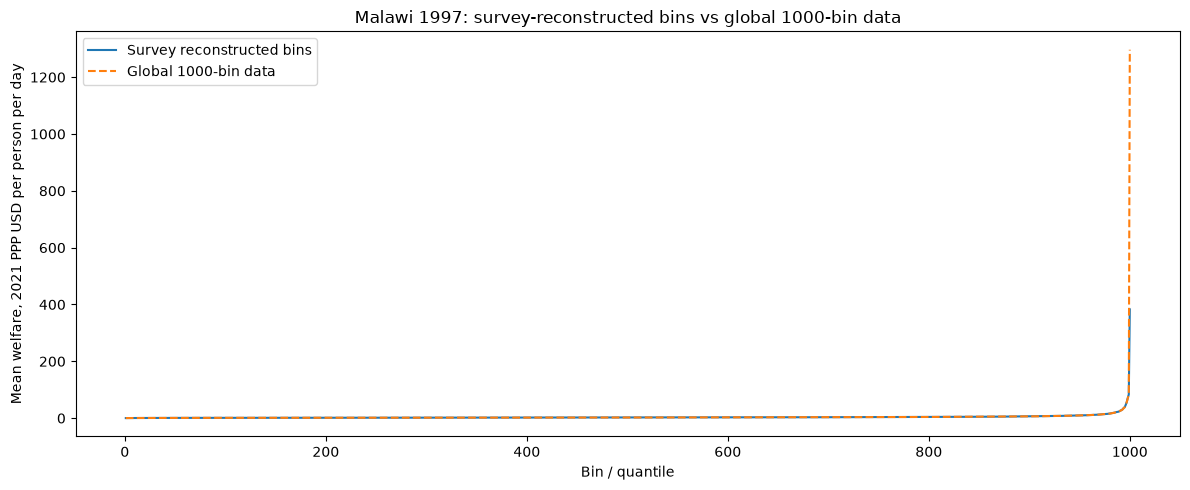

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    mwi_bin_comparison["quantile"],
    mwi_bin_comparison["survey_bin_welf"],
    label="Survey reconstructed bins",
    linewidth=1.5,
)

ax.plot(
    mwi_bin_comparison["quantile"],
    mwi_bin_comparison["global_bin_welf"],
    label="Global 1000-bin data",
    linewidth=1.5,
    linestyle="--",
)

ax.set_title("Malawi 1997: survey-reconstructed bins vs global 1000-bin data")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()

plt.tight_layout()
plt.show()

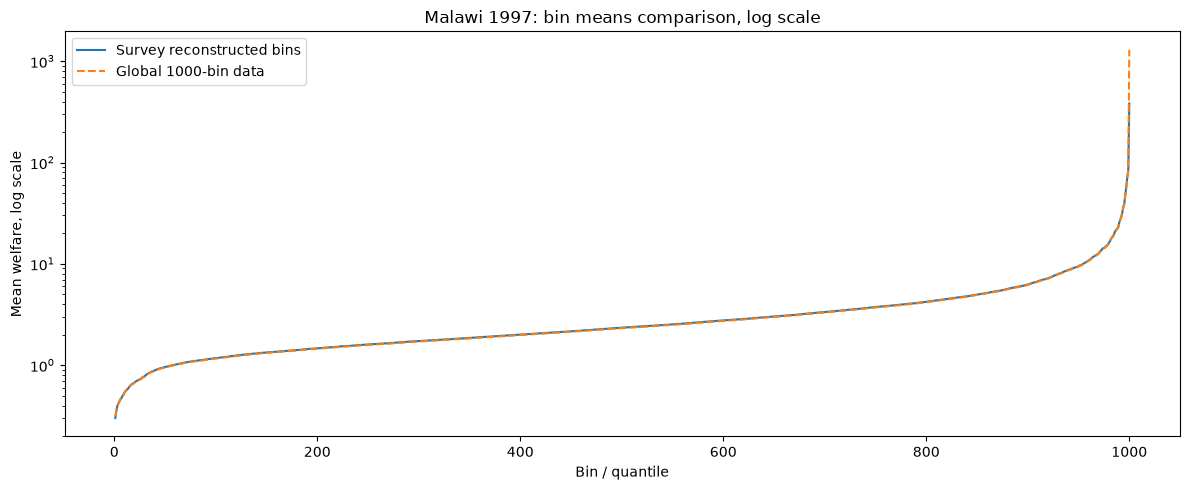

In [51]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    mwi_bin_comparison["quantile"],
    mwi_bin_comparison["survey_bin_welf"],
    label="Survey reconstructed bins",
    linewidth=1.5,
)

ax.plot(
    mwi_bin_comparison["quantile"],
    mwi_bin_comparison["global_bin_welf"],
    label="Global 1000-bin data",
    linewidth=1.5,
    linestyle="--",
)

ax.set_yscale("log")
ax.set_title("Malawi 1997: bin means comparison, log scale")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, log scale")
ax.legend()

plt.tight_layout()
plt.show()

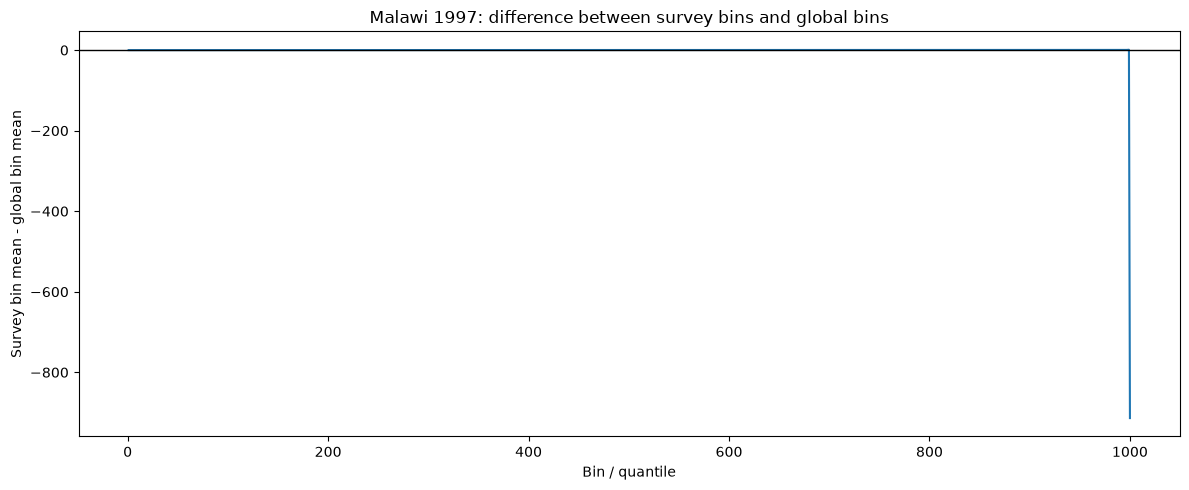

In [52]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    mwi_bin_comparison["quantile"],
    mwi_bin_comparison["diff_survey_minus_global"],
    linewidth=1.5,
)

ax.axhline(0, color="black", linewidth=1)
ax.set_title("Malawi 1997: difference between survey bins and global bins")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Survey bin mean - global bin mean")

plt.tight_layout()
plt.show()

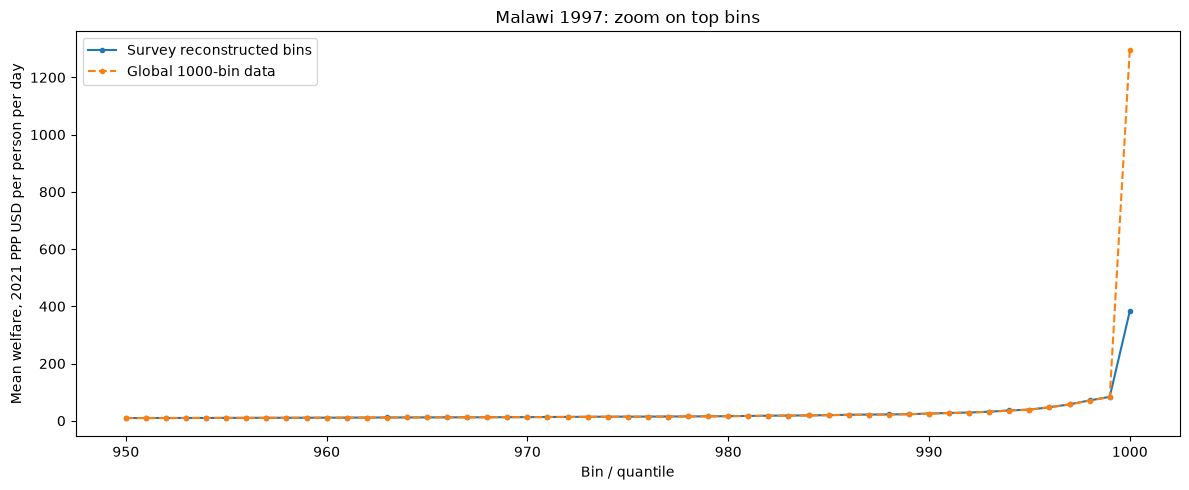

In [53]:
top_zoom = mwi_bin_comparison[mwi_bin_comparison["quantile"] >= 950]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    top_zoom["quantile"],
    top_zoom["survey_bin_welf"],
    label="Survey reconstructed bins",
    marker="o",
    markersize=3,
    linewidth=1.5,
)

ax.plot(
    top_zoom["quantile"],
    top_zoom["global_bin_welf"],
    label="Global 1000-bin data",
    marker="o",
    markersize=3,
    linewidth=1.5,
    linestyle="--",
)

ax.set_title("Malawi 1997: zoom on top bins")
ax.set_xlabel("Bin / quantile")
ax.set_ylabel("Mean welfare, 2021 PPP USD per person per day")
ax.legend()

plt.tight_layout()
plt.show()